In [32]:
import os
from IPython.display import display, HTML
from bs4 import BeautifulSoup
import pandas as pd
import eli5
from eli5.sklearn import PermutationImportance
import pandas as pd
from scipy.stats import zscore
import numpy as np
from numpy import mean
from numpy import std
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
from itertools import combinations
from pandas import DataFrame
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import GradientBoostingRegressor
import lightgbm as xgb
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.model_selection import RepeatedKFold
from numpy import absolute
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import random
import shap
import re
random_seed = 3031

np.random.seed(random_seed)
random.seed(random_seed)

# Prepare the data

In [33]:
v1 = pd.read_excel("/home/nick/PycharmProjects/Engineering_EKB/data/new_dataset_1.xlsx")
v3 = pd.read_excel("/home/nick/PycharmProjects/Engineering_EKB/data/new_dataset_3.xlsx")
v4 = pd.read_excel("/home/nick/PycharmProjects/Engineering_EKB/data/new_dataset_4.xlsx")
v5 = pd.read_excel("/home/nick/PycharmProjects/Engineering_EKB/data/new_dataset_5.xlsx")
v6 = pd.read_excel("/home/nick/PycharmProjects/Engineering_EKB/data/new_dataset_6.xlsx")

vavg = pd.concat([v1, v3, v4, v5, v6]).groupby(level=0).mean()
vavg = vavg.drop(['DELTA30'], axis=1)
df = pd.read_excel('/home/nick/PycharmProjects/Engineering_EKB/data/new_df_66.xlsx', engine='openpyxl')
seq_and_y = df.iloc[:, 126:]
vavg = pd.concat([vavg, seq_and_y], axis=1)

#
# Q1 = np.percentile(vavg['DELTA30'], 5)
# Q3 = np.percentile(vavg['DELTA30'], 95)
# IQR = Q3 - Q1
#
# # Define the lower and upper bounds for outlier detection
# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR
# # Filter out the outliers
# data_filtered = vavg[(vavg['DELTA30'] >= lower_bound) & (v1['DELTA30'] <= upper_bound)]
#
# # Separate the filtered X and Y
# X = data_filtered.drop('DELTA30', axis=1)
# Y = data_filtered['DELTA30']
# #
X = vavg.drop(['DELTA30'], axis=1)
Y = vavg['DELTA30']


scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)
# if hte feature ends with .1 remove the .1
X.columns = [col.split('.1')[0] if col != 'h_3.10' else col for col in X.columns]
data_clean = pd.concat([X, Y], axis=1)





In [34]:
#get all the columns up to val_st
Seq_MD_MDpocket = X
MDpocket = X.iloc[:, :80]
MD = X.iloc[:, 80:112]
Seq = X.iloc[:, 112:]
Seq_MD = X.iloc[:, 80:]
MD_MDpocket = X.iloc[:, :112]
Seq_MDpocket = pd.concat([MDpocket, Seq], axis =1)

Split train and test sets

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=random_seed)

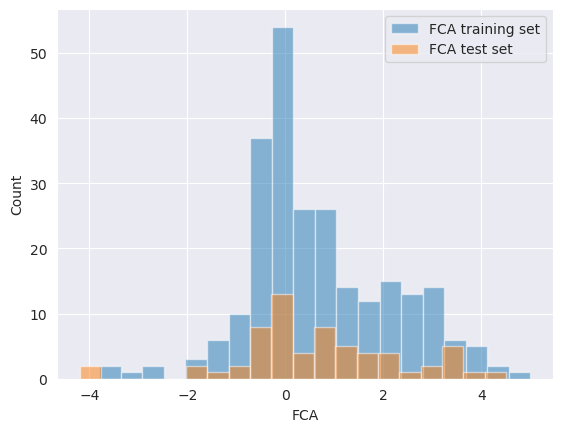

In [36]:
# plot the distribution of y_test on top of the distribution of y_train
fig, ax = plt.subplots()
ax.hist(y_train, bins=20, alpha=0.5, label='FCA training set')
ax.hist(y_test, bins=20, alpha=0.5, label='FCA test set')
# label x axis as 'FAC'
ax.set_xlabel('FCA')
# label y axis as 'count'
ax.set_ylabel('Count')
ax.legend(loc='upper right')
plt.show()

In [37]:
# count how many negative y are in the train and test sets
print('y_train negative values: ', sum(y_train < 0))
print('y_test negative values: ', sum(y_test < 0))
print('y_train positive values: ', sum(y_train >= 0))
print('y_test positive values: ', sum(y_test >= 0))

y_train negative values:  77
y_test negative values:  21
y_train positive values:  172
y_test positive values:  42


In [38]:
# print average of y_train and y_test
print('y_train average: ', np.mean(y_train))
print('y_test average: ', np.mean(y_test))

y_train average:  0.6895582329317269
y_test average:  0.6968253968253968


In [39]:
# print y_train standard deviation
print('y_train standard deviation: ', np.std(y_train))

y_train standard deviation:  1.478592692740836


Parameter search space

In [40]:
parameters = {'learning_rate': [0.001,0.004,0.008,0.01,0.02,0.03,0.04,0.05,0.06,0.07,
                                0.08,0.09,0.1,0.2,0.4,0.6,0.8,1],
              'max_depth': range(1,100,10),
              'num_leaves': range(2,100,10),
              'colsample_bytree': [0.1,0.2,0.4,0.8,1],
              'min_split_gain': range(0,20,1),
              'n_estimators': range(10,1000,10),
              "reg_alpha"   : [0.1,0.2,0.4,0.6,0.8,1],
              "reg_lambda"  : range(1,10,1)
          }

# Randomized search

######## COMPARING DATASET ORIGIN #################

In [41]:
# Create an empty DataFrame
datasets = [Seq, Seq_MD, Seq_MD_MDpocket, Seq_MDpocket, MD_MDpocket, MD, MDpocket]
best_params = []
best_estimators = []
all_results = []
results_table = pd.DataFrame(index=['Seq', 'Seq_MD', 'Seq_MD_MDpocket', 'Seq_MDpocket', 'MD_MDpocket', 'MD', 'MDPocket'])
r2_values = []
rmse_values = []
mae_values = []

def mape(actual, pred):
    actual, pred = np.array(actual), np.array(pred)
    return np.mean(np.abs((actual - pred) / actual)) * 100
# Iterate over datasets
for i, dataset in enumerate(datasets):
    X_train, X_test, y_train, y_test = train_test_split(dataset, Y, test_size=0.2, random_state=random_seed)
    xgb_model = LGBMRegressor(random_state=random_seed)

    grid_obj_xgb = RandomizedSearchCV(xgb_model, parameters, cv=5, n_iter=15,
                                      scoring='neg_mean_absolute_error', verbose=0, n_jobs=12, random_state=random_seed) #random_state=7)
    grid_obj_xgb.fit(X_train, y_train, verbose=1)

    y_pred_train = grid_obj_xgb.predict(X_train)
    y_pred_test = grid_obj_xgb.predict(X_test)

    err_xgb_train = mean_absolute_error(y_train, y_pred_train, multioutput='raw_values')
    best_estimators.append(grid_obj_xgb.best_estimator_)
    best_params.append(grid_obj_xgb.best_params_)

    # Evaluation
    results = {}
    results['best_estimator'] = grid_obj_xgb.best_estimator_

    # Predict on test set
    y_pred = grid_obj_xgb.predict(X_test)

    # Calculate metrics
    results['r2_score'] = r2_score(y_test, y_pred)
    r2_values.append(r2_score(y_test, y_pred))
    #results['mean_absolute_perc_error'] = mape(y_test, y_pred)
    #results['std_absolute_perc_error'] = np.std(np.abs((y_test - y_pred) / y_pred))
    results['mean_absolute_error'] = mean_absolute_error(y_test, y_pred)
    # get the standard deviation of the MAEs
    results['std_absolute_error'] = np.std(np.abs(y_test - y_pred))
    results['root_mean_squared_error'] = np.sqrt(mean_squared_error(y_test, y_pred))
    # get std of sequared errors
    results['std_squared_error'] = np.std((y_test - y_pred) ** 2)

    # Calculate residuals
    residuals = y_test - y_pred
    max_error = max(residuals) if abs(max(residuals)) > abs(min(residuals)) else min(residuals)
    max_idx = list(residuals).index(max(residuals)) if abs(max(residuals)) > abs(min(residuals)) else list(
        residuals).index(min(residuals))
    max_true, max_pred = y_test.iloc[max_idx], y_pred[max_idx]
    results['max_error'] = abs(max_error)
    results['max_true'] = max_true
    results['max_predicted'] = max_pred
    results['residuals_std'] = np.std(residuals)
    results['average_residuals'] = np.mean(abs(residuals))
    results['std_deviation'] = np.std(residuals)
    rmse_values.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    mae_values.append(mean_absolute_error(y_test, y_pred))
    all_results.append(results)

    # fig, ax = plt.subplots()
    # ax.hist(y_pred_test, bins=20, alpha=0.5, label='Predicted Y')
    # ax.hist(y_test, bins=20, alpha=0.5, label='True Y')
    # ax.legend(loc='upper right')
    # plt.show()

# Create the results table
results_dict = {
    'Best Estimator': [str(result['best_estimator']) for result in all_results],
    'R2 Score': [round(result['r2_score'], 2) for result in all_results],
    #'Mean Absolute Perc Error': [round(result['mean_absolute_perc_error'], 2) for result in all_results],
    #'Std Absolute Perc Error': [round(result['std_absolute_perc_error'], 2) for result in all_results],
    'Mean Absolute Error': ["{:,.2f}".format(result['mean_absolute_error']) for result in all_results],
    'Std Absolute Error': ["{:,.2f}".format(result['std_absolute_error']) for result in all_results],
    'Root Mean Squared Error': ["{:,.2f}".format(result['root_mean_squared_error']) for result in all_results],
    'Std Squared Error': ["{:,.2f}".format(result['std_squared_error']) for result in all_results],
    'Max Error': ["{:,.2f}".format(result['max_error']) for result in all_results],
    'Max True': ["{:,.2f}".format(result['max_true']) for result in all_results],
    'Max Predicted': ["{:,.2f}".format(result['max_predicted']) for result in all_results],
    'Average Error': [result['average_residuals'] for result in all_results],
    'Residuals Std': ["{:,.2f}".format(result['residuals_std']) for result in all_results],
}

results_table = pd.DataFrame(results_dict, index=results_table.index)




'verbose' argument is deprecated and will be removed in a future release of LightGBM. Pass 'log_evaluation()' callback via 'callbacks' argument instead.
'verbose' argument is deprecated and will be removed in a future release of LightGBM. Pass 'log_evaluation()' callback via 'callbacks' argument instead.
/usr/ulocal/anaconda3/envs/Engineering_EKB/lib/python3.8/site-packages/lightgbm/sklearn.py:736: UserWarning: 'verbose' argument is deprecated and will be removed in a future release of LightGBM. Pass 'log_evaluation()' callback via 'callbacks' argument instead.
  _log_warning("'verbose' argument is deprecated and will be removed in a future release of LightGBM. "
/usr/ulocal/anaconda3/envs/Engineering_EKB/lib/python3.8/site-packages/lightgbm/sklearn.py:736: UserWarning: 'verbose' argument is deprecated and will be removed in a future release of LightGBM. Pass 'log_evaluation()' callback via 'callbacks' argument instead.
  _log_warning("'verbose' argument is deprecated and will be remov

In [42]:
results_table

,Best Estimator,R2 Score,Mean Absolute Error,Std Absolute Error,Root Mean Squared Error,Std Squared Error,Max Error,Max True,Max Predicted,Average Error,Residuals Std
Seq,"LGBMRegressor(colsample_bytree=0.8, learning_r...",0.47,0.85,0.86,1.21,3.29,4.60,-4.20,0.40,0.851938,1.21
Seq_MD,"LGBMRegressor(colsample_bytree=0.8, learning_r...",0.50,0.83,0.84,1.18,3.19,4.51,-4.20,0.31,0.829303,1.18
Seq_MD_MDpocket,"LGBMRegressor(colsample_bytree=0.8, learning_r...",0.45,0.84,0.91,1.24,3.49,4.78,-4.20,0.58,0.836820,1.24
Seq_MDpocket,"LGBMRegressor(colsample_bytree=0.8, learning_r...",0.41,0.86,0.95,1.28,3.73,4.95,-4.20,0.75,0.857435,1.28
MD_MDpocket,"LGBMRegressor(colsample_bytree=0.8, learning_r...",0.21,1.08,1.02,1.48,4.35,5.12,-4.20,0.92,1.076091,1.48
MD,"LGBMRegressor(colsample_bytree=0.8, learning_r...",0.22,1.08,1.00,1.47,4.28,5.00,-4.20,0.80,1.076739,1.47
MDPocket,"LGBMRegressor(colsample_bytree=0.8, learning_r...",0.20,1.16,0.94,1.49,3.71,4.51,-4.20,0.31,1.159177,1.49


In [43]:
results_table

,Best Estimator,R2 Score,Mean Absolute Error,Std Absolute Error,Root Mean Squared Error,Std Squared Error,Max Error,Max True,Max Predicted,Average Error,Residuals Std
Seq,"LGBMRegressor(colsample_bytree=0.8, learning_r...",0.47,0.85,0.86,1.21,3.29,4.60,-4.20,0.40,0.851938,1.21
Seq_MD,"LGBMRegressor(colsample_bytree=0.8, learning_r...",0.50,0.83,0.84,1.18,3.19,4.51,-4.20,0.31,0.829303,1.18
Seq_MD_MDpocket,"LGBMRegressor(colsample_bytree=0.8, learning_r...",0.45,0.84,0.91,1.24,3.49,4.78,-4.20,0.58,0.836820,1.24
Seq_MDpocket,"LGBMRegressor(colsample_bytree=0.8, learning_r...",0.41,0.86,0.95,1.28,3.73,4.95,-4.20,0.75,0.857435,1.28
MD_MDpocket,"LGBMRegressor(colsample_bytree=0.8, learning_r...",0.21,1.08,1.02,1.48,4.35,5.12,-4.20,0.92,1.076091,1.48
MD,"LGBMRegressor(colsample_bytree=0.8, learning_r...",0.22,1.08,1.00,1.47,4.28,5.00,-4.20,0.80,1.076739,1.47
MDPocket,"LGBMRegressor(colsample_bytree=0.8, learning_r...",0.20,1.16,0.94,1.49,3.71,4.51,-4.20,0.31,1.159177,1.49


In [51]:
results_table['Best Estimator']['Seq_MD']

'LGBMRegressor(colsample_bytree=0.8, learning_rate=0.008, max_depth=41,\n              min_split_gain=1, n_estimators=520, num_leaves=42,\n              random_state=3031, reg_alpha=0.6, reg_lambda=7)'

In [60]:
dataset_names = ['Seq', 'Seq_MD', 'Seq_MD_MDpocket', 'Seq_MDpocket', 'MD_MDpocket', 'MD', 'MDPocket']

# Lists to store mean and std values for each metric
mean_metrics = []
std_metrics = []

# Initialize lists to store R2, RMSE, and MAE dataframes for each dataset
r2_values_bs = []
rmse_values_bs = []
mae_values_bs = []

# Iterate over datasets with a progress bar
for dataset, dataset_name in zip(datasets, dataset_names):
    X_train, X_test, y_train, y_test = train_test_split(dataset, Y, test_size=0.2, random_state=random_seed)

    # Get hyperparameters for this dataset
    param_string = results_table['Best Estimator'][dataset_name]
    params = dict(re.findall(r"(\w+)=(.*?)(?:(?:,|$|\n\s+)|\))", param_string))
    reg_lambda = params.get('reg_lambda', '')
    params['reg_lambda'] = reg_lambda.strip(")")

    # Convert values to their appropriate data types if needed
    params = {k: eval(v) if v.isdigit() else v for k, v in params.items()}

    # Initialize lists to store R2, RMSE, and MAE for this dataset
    bootstrap_r2_scores = []
    bootstrap_rmse_scores = []
    bootstrap_mae_scores = []

    # Number of bootstrap iterations
    n_bootstrap_iterations = 500

    # Create a tqdm progress bar for the loop
    for _ in tqdm(range(n_bootstrap_iterations), desc=f'Bootstrap for {dataset_name}'):
        # Create a bootstrap sample by randomly selecting with replacement
        bootstrap_indices = np.random.choice(len(X_train), size=len(X_train), replace=True)
        X_train_bootstrap = X_train.iloc[bootstrap_indices]
        y_train_bootstrap = y_train.iloc[bootstrap_indices]

        # Train your model on the bootstrap sample with hyperparameters
        xgb_model = LGBMRegressor(**params)
        xgb_model.fit(X_train_bootstrap, y_train_bootstrap)

        # Make predictions on the test set
        y_pred = xgb_model.predict(X_test)

        # Calculate metrics for this bootstrap iteration
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)

        # Append the metrics to their respective lists for this dataset
        bootstrap_r2_scores.append(r2)
        bootstrap_rmse_scores.append(rmse)
        bootstrap_mae_scores.append(mae)

    # Create dataframes to store R2, RMSE, and MAE for this dataset
    r2_df = pd.DataFrame({'R2': bootstrap_r2_scores})
    rmse_df = pd.DataFrame({'RMSE': bootstrap_rmse_scores})
    mae_df = pd.DataFrame({'MAE': bootstrap_mae_scores})

    # Append the dataframes to the lists
    r2_values_bs.append(r2_df)
    rmse_values_bs.append(rmse_df)
    mae_values_bs.append(mae_df)

Bootstrap for MDPocket: 100%|██████████| 500/500 [5:58:05<00:00, 42.97s/it]  


In [61]:
# # Import necessary library
# import pandas as pd
#
# # Create an Excel writer object
# with pd.ExcelWriter('metrics.xlsx') as writer:
#     # Iterate through the lists and dataset names and save each DataFrame to a different sheet
#     for dataset_name, r2_df, rmse_df, mae_df in zip(dataset_names, r2_values_bs, rmse_values_bs, mae_values_bs):
#         # Use the dataset_name to create unique sheet names
#         r2_df.to_excel(writer, sheet_name=f'{dataset_name}_R2')
#         rmse_df.to_excel(writer, sheet_name=f'{dataset_name}_RMSE')
#         mae_df.to_excel(writer, sheet_name=f'{dataset_name}_MAE')


In [224]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Load the Excel file
with pd.ExcelFile('/home/nick/PycharmProjects/Engineering_EKB/Python_scripts/metrics.xlsx') as xls:
    # Get the sheet names for R2
    r2_sheet_names = [sheet for sheet in xls.sheet_names if 'R2' in sheet]
    print(len(r2_sheet_names))

    # Create an empty DataFrame to hold the combined data
    all_data = pd.DataFrame()

    for sheet_name in r2_sheet_names:
        # Read the data from the current sheet
        data = pd.read_excel(xls, sheet_name=sheet_name)


        # Add a 'group' column to indicate the sheet name
        data['group'] = sheet_name

        # Append this data to the combined DataFrame
        all_data = pd.concat([all_data, data], ignore_index=True)

    # Now you have all data combined with a 'group' column indicating the sheet name
    formula = 'R2 ~ C(group)'
    model = ols(formula, all_data).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(f'ANOVA table:\n', anova_table)

    # Perform Tukey HSD test
    tukey = pairwise_tukeyhsd(all_data['R2'], all_data['group'])
    print(f'Tukey HSD results:\n', tukey)


7
ANOVA table:
              sum_sq      df            F  PR(>F)
C(group)  70.672951     6.0  6597.346874     0.0
Residual   6.236361  3493.0          NaN     NaN
Tukey HSD results:
             Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2       meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------
       MDPocket_R2     MD_MDpocket_R2   0.0827    0.0  0.0748  0.0905   True
       MDPocket_R2              MD_R2   0.0702    0.0  0.0623  0.0781   True
       MDPocket_R2 Seq_MD_MDpocket_R2   0.3237    0.0  0.3158  0.3316   True
       MDPocket_R2          Seq_MD_R2   0.3511    0.0  0.3432   0.359   True
       MDPocket_R2    Seq_MDpocket_R2   0.3078    0.0     0.3  0.3157   True
       MDPocket_R2             Seq_R2   0.3483    0.0  0.3404  0.3561   True
    MD_MDpocket_R2              MD_R2  -0.0124 0.0001 -0.0203 -0.0046   True
    MD_MDpocket_R2 Seq_MD_MDpocket_R2    0.241 

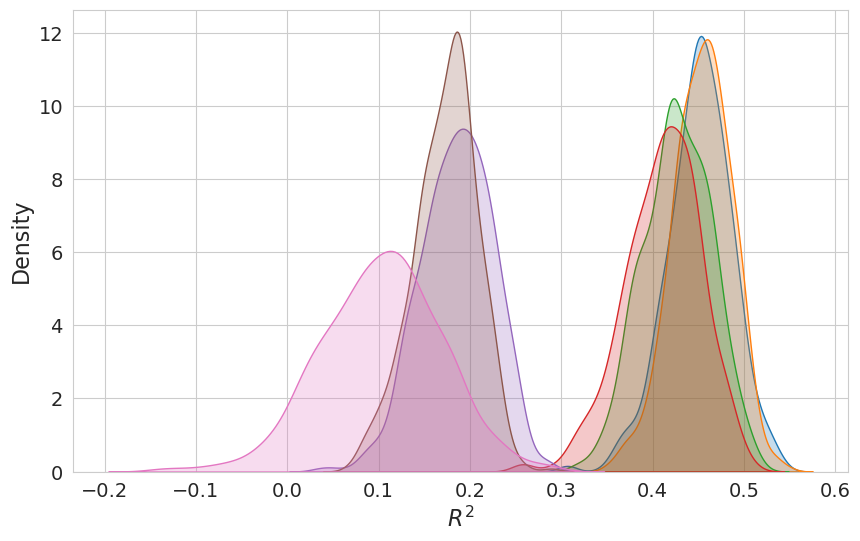

In [227]:
import seaborn as sns
import matplotlib.pyplot as plt
labels = all_data['group'].unique()
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a figure and axis object
fig, ax = plt.subplots(figsize=(10,6))

# Iterate through each group and plot the KDE
for label in labels:
    group_data = all_data[all_data['group'] == label]
    sns.kdeplot(data=group_data, x='R2', ax=ax, label=label, fill=True)

# Optionally, set the title and labels
# ax.set_title('Distribution of R2 values across different groups')
ax.set_xlabel(r'$R^2$', fontsize=16)
ax.set_ylabel('Density', fontsize=16)
ax.tick_params(axis='x', labelsize=14)  # Adjust the x-axis tick label size
ax.tick_params(axis='y', labelsize=14)


handles, labels = ax.get_legend_handles_labels()
modified_labels = [label.rsplit('_', 1)[0].replace('_', '+') for label in labels]
# Ensure the legend is displayed
# plt.legend(handles, modified_labels, title='Group', title_fontsize='14', fontsize='12', loc='upper left')
# plt.savefig('/home/nick/PycharmProjects/Engineering_EKB/Figures/R2_boostrap.png')
# Display the plot
plt.show()


In [222]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Load the Excel file
with pd.ExcelFile('/home/nick/PycharmProjects/Engineering_EKB/Python_scripts/metrics.xlsx') as xls:
    # Get the sheet names for R2
    rmse_sheet_names = [sheet for sheet in xls.sheet_names if 'RMSE' in sheet]

    # Create an empty DataFrame to hold the combined data
    all_data = pd.DataFrame()

    for sheet_name in rmse_sheet_names:
        # Read the data from the current sheet
        data = pd.read_excel(xls, sheet_name=sheet_name)


        # Add a 'group' column to indicate the sheet name
        data['group'] = sheet_name

        # Append this data to the combined DataFrame
        all_data = pd.concat([all_data, data], ignore_index=True)

    # Now you have all data combined with a 'group' column indicating the sheet name
    formula = 'RMSE ~ C(group)'
    model = ols(formula, all_data).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(f'ANOVA table:\n', anova_table)

    # Perform Tukey HSD test
    tukey = pairwise_tukeyhsd(all_data['RMSE'], all_data['group'])
    print(f'Tukey HSD results:\n', tukey)


ANOVA table:
              sum_sq      df            F  PR(>F)
C(group)  70.032013     6.0  6667.870931     0.0
Residual   6.114441  3493.0          NaN     NaN
Tukey HSD results:
               Multiple Comparison of Means - Tukey HSD, FWER=0.05               
       group1               group2        meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------------------
       MDPocket_RMSE     MD_MDpocket_RMSE  -0.0739    0.0 -0.0817 -0.0661   True
       MDPocket_RMSE              MD_RMSE  -0.0623    0.0 -0.0701 -0.0545   True
       MDPocket_RMSE Seq_MD_MDpocket_RMSE  -0.3163    0.0 -0.3241 -0.3085   True
       MDPocket_RMSE          Seq_MD_RMSE  -0.3467    0.0 -0.3545 -0.3389   True
       MDPocket_RMSE    Seq_MDpocket_RMSE  -0.2991    0.0 -0.3069 -0.2913   True
       MDPocket_RMSE             Seq_RMSE  -0.3436    0.0 -0.3514 -0.3358   True
    MD_MDpocket_RMSE              MD_RMSE   0.0116 0.0003  0.0038  0.0194   True
    MD_MD

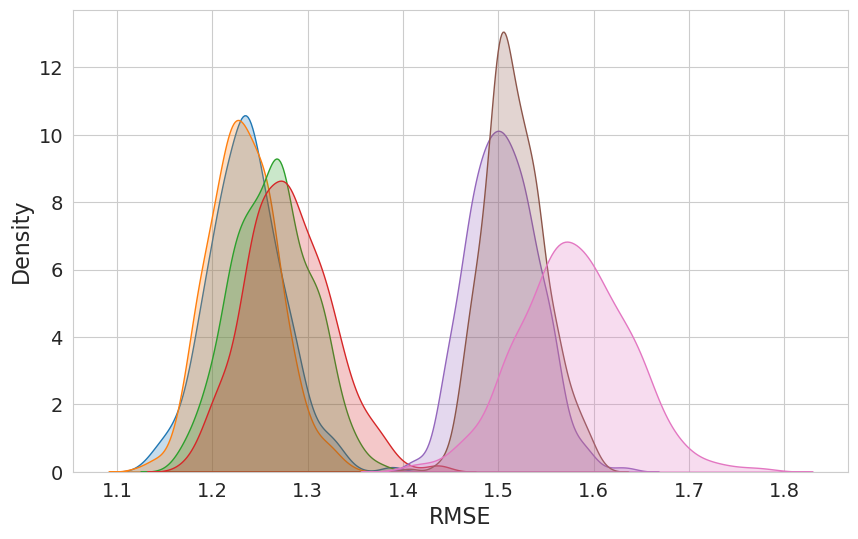

In [223]:
# Assume all_data is your DataFrame
labels = all_data['group'].unique()

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a figure and axis object
fig, ax = plt.subplots(figsize=(10,6))

# Iterate through each group and plot the KDE
for label in labels:
    group_data = all_data[all_data['group'] == label]
    sns.kdeplot(data=group_data, x='RMSE', ax=ax, label=label, fill=True)

# Optionally, set the title and labels


ax.tick_params(axis='x', labelsize=14)  # Adjust the x-axis tick label size
ax.tick_params(axis='y', labelsize=14)
ax.set_xlabel('RMSE', fontsize=16)
ax.set_ylabel('Density', fontsize=16)

handles, labels = ax.get_legend_handles_labels()
modified_labels = [label.rsplit('_', 1)[0].replace('_', '+') for label in labels]
# Ensure the legend is displayed
# plt.legend(handles, modified_labels, title='Group', title_fontsize='14', fontsize='12')
# plt.savefig('/home/nick/PycharmProjects/Engineering_EKB/Figures/RMSE_boostrap.png')
# Display the plot
plt.show()

In [186]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Load the Excel file
with pd.ExcelFile('/home/nick/PycharmProjects/Engineering_EKB/Python_scripts/metrics.xlsx') as xls:
    # Get the sheet names for R2
    mae_sheet_names = [sheet for sheet in xls.sheet_names if 'MAE' in sheet]

    # Create an empty DataFrame to hold the combined data
    all_data = pd.DataFrame()

    for sheet_name in mae_sheet_names:
        # Read the data from the current sheet
        data = pd.read_excel(xls, sheet_name=sheet_name)


        # Add a 'group' column to indicate the sheet name
        data['group'] = sheet_name

        # Append this data to the combined DataFrame
        all_data = pd.concat([all_data, data], ignore_index=True)

    # Now you have all data combined with a 'group' column indicating the sheet name
    formula = 'MAE ~ C(group)'
    model = ols(formula, all_data).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(f'ANOVA table:\n', anova_table)

    # Perform Tukey HSD test
    tukey = pairwise_tukeyhsd(all_data['MAE'], all_data['group'])
    print(f'Tukey HSD results:\n', tukey)


ANOVA table:
              sum_sq      df            F  PR(>F)
C(group)  59.952970     6.0  6651.608718     0.0
Residual   5.247245  3493.0          NaN     NaN
Tukey HSD results:
              Multiple Comparison of Means - Tukey HSD, FWER=0.05              
       group1              group2       meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------------
       MDPocket_MAE              MD_MAE  -0.1168    0.0  -0.124 -0.1095   True
       MDPocket_MAE     MD_MDpocket_MAE  -0.1253    0.0 -0.1325  -0.118   True
       MDPocket_MAE             Seq_MAE  -0.3418    0.0  -0.349 -0.3345   True
       MDPocket_MAE          Seq_MD_MAE  -0.3398    0.0  -0.347 -0.3325   True
       MDPocket_MAE Seq_MD_MDpocket_MAE  -0.3312    0.0 -0.3384 -0.3239   True
       MDPocket_MAE    Seq_MDpocket_MAE  -0.3227    0.0 -0.3299 -0.3155   True
             MD_MAE     MD_MDpocket_MAE  -0.0085 0.0093 -0.0157 -0.0013   True
             MD_MAE          

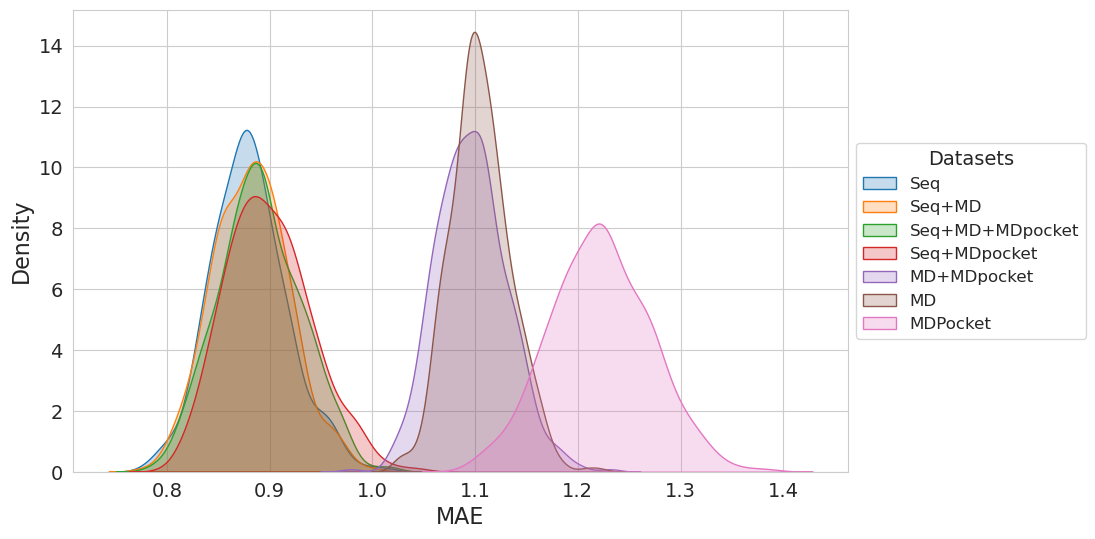

In [221]:
# Assume all_data is your DataFrame
labels = all_data['group'].unique()

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a figure and axis object
fig, ax = plt.subplots(figsize=(10,6))

# ... rest of the plotting code ...

# Iterate through each group and plot the KDE
for label in labels:
    group_data = all_data[all_data['group'] == label]
    sns.kdeplot(data=group_data, x='MAE', ax=ax, label=label, fill=True)

# Optionally, set the title and labels
# ax.set_title('Distribution of MAE values across different groups')
ax.tick_params(axis='x', labelsize=14)  # Adjust the x-axis tick label size
ax.tick_params(axis='y', labelsize=14)
ax.set_xlabel('MAE', fontsize=16)
ax.set_ylabel('Density', fontsize=16)

handles, labels = ax.get_legend_handles_labels()
modified_labels = [label.rsplit('_', 1)[0].replace('_', '+') for label in labels]


# Ensure the legend is displayed
legend = plt.legend(handles, modified_labels, title='Datasets', title_fontsize='14', fontsize='20', loc='center left', bbox_to_anchor=(1, 0.5))
plt.legend(handles, modified_labels, title='Datasets', title_fontsize='14', fontsize='12', loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig('/home/nick/PycharmProjects/Engineering_EKB/Figures/MAE_boostrap.png', bbox_extra_artists=(legend,), bbox_inches='tight')
# Display the plot
plt.show()

In [216]:
from PIL import Image

# Load your images
img1 = Image.open('/home/nick/PycharmProjects/Engineering_EKB/Figures/R2_boostrap.png')
img2 = Image.open('/home/nick/PycharmProjects/Engineering_EKB/Figures/RMSE_boostrap.png')
img3 = Image.open('/home/nick/PycharmProjects/Engineering_EKB/Figures/MAE_boostrap.png')
print(img2.size)
print(img3.size)
# Define cropping boxes (left, upper, right, lower)
crop_box1 = (0, 0, img1.width- 100, img1.height )  # Adjust the values as necessary
crop_box2 = (0, 0, img2.width-100, img2.height)  # Adjust the values as necessary
crop_box3 = (0, 0, img3.width + 100, img3.height+75)       # Adjust the values as necessary

# Crop the images
img1 = img1.crop(crop_box1)
img2 = img2.crop(crop_box2)
img3 = img3.crop(crop_box3)

# Get dimensions of the individual images
width1, height1 = img1.size
width2, height2 = img2.size
width3, height3 = img3.size

# Create a new image with a width that is the sum of the widths of the individual images
# and a height that is the maximum height of the individual images
total_width = width1 + width2 + width3
max_height = max(height1, height2, height3)

composite_img = Image.new('RGBA', (total_width, max_height))

# Paste each image into the composite image
composite_img.paste(img1, (0, 0))
composite_img.paste(img2, (width1, 0))
composite_img.paste(img3, (width1 + width2, 0))

# Save the composite image
composite_img.save('/home/nick/PycharmProjects/Engineering_EKB/Figures/combined_metrics_distributions.png')

# Optionally, display the composite image
composite_img.show()


(1000, 600)
(1079, 525)


In [ ]:
performance = []
split = []
gain = []
for i in range(len(datasets)):
    param_string = results_table['Best Estimator'][i]
    params = dict(re.findall(r"(\w+)=(.*?)(?:(?:,|$|\n\s+)|\))", param_string))
    reg_lambda = params.get('reg_lambda', '')
    params['reg_lambda'] = reg_lambda.strip(")")

    # Convert values to their appropriate data types if needed
    params = {k: eval(v) if v.isdigit() else v for k, v in params.items()}

    # Create the LGBMRegressor object with the extracted parameters
    Best_model = LGBMRegressor(**params)
    X_train, X_test, y_train, y_test = train_test_split(datasets[i], Y, test_size=0.2, random_state=random_seed)
    eval_set = [(X_train, y_train), (X_test, y_test)]

    Best_model.fit(X_train, y_train, eval_metric=["mae", "rmse"], eval_set=eval_set, verbose=True, early_stopping_rounds=10)
    y_pred = Best_model.predict(X_test)
    predictions = [value for value in y_pred]
    results = Best_model.evals_result_
    perm = PermutationImportance(Best_model, random_state=random_seed).fit(X_test, y_test)

    weights_perm = eli5.show_weights(perm, feature_names=X_test.columns.tolist())
    performance.append(weights_perm)
    weights_split = eli5.show_weights(Best_model, importance_type="split")
    split.append(weights_split)
    weights_gain = eli5.show_weights(Best_model, importance_type="gain")
    gain.append(weights_gain)


In [ ]:
# Create an empty DataFrame
performances = pd.DataFrame()

for i, html in enumerate(performance):
    # Parse the HTML
    soup = BeautifulSoup(html.data, 'html.parser')

    # Find the table element in the HTML
    table = soup.find('table')

    # Convert the table to a DataFrame
    temp_df = pd.read_html(str(table))[0]

    # Rename the weight and feature columns
    temp_df.rename(columns={'weight': f'Performance {i+1} Weight', 'feature': f'Performance {i+1} Feature'}, inplace=True)

    # Append the temporary DataFrame to the main DataFrame
    performances = pd.concat([performances, temp_df], axis=1)

# Display the combined DataFrame
performances



In [ ]:
# Convert 'Weight' column to numeric values and extract the first digit
Seq_MD_perf = performances.iloc[:15, 2:4]
# Convert 'Weight' column to numeric values and extract the first digit

Seq_MD_perf['Weight'] = pd.to_numeric(Seq_MD_perf['Weight'].str.extract(r'(\d+\.\d+|\d+)', expand=False), errors='coerce')
Seq_MD_perf_sorted = Seq_MD_perf.sort_values(by='Weight', ascending=True)

# Create a horizontal bar plot
plt.figure(figsize=(10, 6))
plt.barh(Seq_MD_perf_sorted['Feature'], Seq_MD_perf_sorted['Weight'], color='blue')
plt.title('Feature Weights (Top 10)')
plt.xlabel('Weight')
plt.ylabel('Feature')
plt.xlim(0, Seq_MD_perf_sorted['Weight'].max()+0.01)  # Set the x-axis range
plt.tight_layout()
plt.show()

In [ ]:
# Convert 'Weight' column to numeric values and extract the first digit and error value
Seq_MD_perf = performances.iloc[:15, 2:4]
Seq_MD_perf[['Weight', 'Error']] = Seq_MD_perf['Weight'].str.extract(r'(\d+\.\d+)\s*±\s*(\d+\.\d+)', expand=True)

# Convert the extracted columns to numeric values
Seq_MD_perf['Weight'] = pd.to_numeric(Seq_MD_perf['Weight'], errors='coerce')
Seq_MD_perf['Error'] = pd.to_numeric(Seq_MD_perf['Error'], errors='coerce')

Seq_MD_perf_sorted = Seq_MD_perf.sort_values(by='Weight', ascending=True)

# Create a horizontal bar plot with error bars
plt.figure(figsize=(10, 6))
plt.barh(Seq_MD_perf_sorted['Feature'], Seq_MD_perf_sorted['Weight'], color='blue')
plt.errorbar(Seq_MD_perf_sorted['Weight'], Seq_MD_perf_sorted['Feature'], xerr=Seq_MD_perf_sorted['Error'], fmt='none', ecolor='black', capsize=4)
plt.xlabel('Weight by Permutation Feature Importance')
plt.ylabel('Feature')
plt.xlim(0, Seq_MD_perf_sorted['Weight'].max() + Seq_MD_perf_sorted['Error'].max() + 0.01)  # Set the x-axis range
plt.tight_layout()

# Save the figure
#plt.savefig('PIF_ranking.png', dpi=1200)
plt.show()


In [ ]:
# Create an empty DataFrame
splits = pd.DataFrame()

for i, html in enumerate(split):
    # Parse the HTML
    soup = BeautifulSoup(html.data, 'html.parser')

    # Find the table element in the HTML
    table = soup.find('table')

    # Convert the table to a DataFrame
    temp_df = pd.read_html(str(table))[0]

    # Rename the weight and feature columns
    temp_df.rename(columns={'weight': f'Performance {i+1} Weight', 'feature': f'Performance {i+1} Feature'}, inplace=True)

    # Append the temporary DataFrame to the main DataFrame
    splits = pd.concat([splits, temp_df], axis=1)

# Display the combined DataFrame
splits


In [ ]:
# Convert 'Weight' column to numeric values and extract the first digit
Seq_MD_splits = splits.iloc[:15, 2:4]
# Convert 'Weight' column to numeric values and extract the first digit

Seq_MD_splits['Weight'] = pd.to_numeric(Seq_MD_splits['Weight'].str.extract(r'(\d+\.\d+|\d+)', expand=False), errors='coerce')
Seq_MD_splits_sorted = Seq_MD_splits.sort_values(by='Weight', ascending=True)

# Create a horizontal bar plot
plt.figure(figsize=(10, 6))
plt.barh(Seq_MD_splits_sorted['Feature'], Seq_MD_splits_sorted['Weight'], color='blue')
plt.xlabel('Weight by Split Importance')
plt.ylabel('Feature')
plt.xlim(0, Seq_MD_splits_sorted['Weight'].max()+0.01)  # Set the x-axis range
plt.tight_layout()
# plt.savefig('PIF_split.png', dpi=1200)
plt.show()

In [ ]:
# Create an empty DataFrame
gains = pd.DataFrame()

for i, html in enumerate(gain):
    # Parse the HTML
    soup = BeautifulSoup(html.data, 'html.parser')

    # Find the table element in the HTML
    table = soup.find('table')

    # Convert the table to a DataFrame
    temp_df = pd.read_html(str(table))[0]

    # Rename the weight and feature columns
    temp_df.rename(columns={'weight': f'Performance {i+1} Weight', 'feature': f'Performance {i+1} Feature'}, inplace=True)

    # Append the temporary DataFrame to the main DataFrame
    gains = pd.concat([gains, temp_df], axis=1)

# Display the combined DataFrame
gains

In [ ]:
# Convert 'Weight' column to numeric values and extract the first digit
Seq_MD_gains = gains.iloc[:15, 2:4]
# Convert 'Weight' column to numeric values and extract the first digit

Seq_MD_gains['Weight'] = pd.to_numeric(Seq_MD_gains['Weight'].str.extract(r'(\d+\.\d+|\d+)', expand=False), errors='coerce')
Seq_MD_gains_sorted = Seq_MD_gains.sort_values(by='Weight', ascending=True)

# Create a horizontal bar plot
plt.figure(figsize=(10, 6))
plt.barh(Seq_MD_gains_sorted['Feature'], Seq_MD_gains_sorted['Weight'], color='blue')

plt.xlabel('Weight by Performance Gain')
plt.ylabel('Feature')
plt.xlim(0, Seq_MD_gains_sorted['Weight'].max()+0.01)  # Set the x-axis range
plt.tight_layout()
#  plt.savefig('PIF_gain.png', dpi=1200)
plt.show()

In [ ]:
import shap

In [ ]:
BestSeqMD = LGBMRegressor(colsample_bytree=0.8, learning_rate=0.008, max_depth=41,
                          min_split_gain=1, n_estimators=520, num_leaves=42,random_state=3031, reg_alpha=0.6, reg_lambda=7)
X_train, X_test, y_train, y_test = train_test_split(Seq_MD, Y, test_size=0.2, random_state=random_seed)
eval_set = [(X_train, y_train), (X_test, y_test)]
BestSeqMD.fit(X_train, y_train, eval_metric=["mae", "rmse"], eval_set=eval_set, verbose=True, early_stopping_rounds=10)
y_pred = BestSeqMD.predict(X_test)
predictions = [value for value in y_pred]
results = BestSeqMD.evals_result_

In [ ]:
shap_values = shap.Explainer(BestSeqMD).shap_values(X_train)

In [ ]:
import matplotlib.pyplot as plt
shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
plt.show()

In [ ]:
f = plt.figure()
shap.summary_plot(shap_values, X_train)

In [ ]:
shap.dependence_plot('halpha', shap_values, X_train, dot_size=32, show=False)
# Set the DPI (dots per inch) to 1200
# plt.savefig('/home/nick/PycharmProjects/Engineering_EKB/Figures/dependence_plot_halpha_SEQMD.png', dpi=1200)

In [ ]:
# fig, ax = plt.subplots()
# heatmap = shap.plots.heatmap(shap_values, show=False, cmap='viridis')
# ax.set_aspect('auto')
#
# # Add colorbar on the side and move it to the right
# cbar = plt.colorbar(heatmap, ax=ax, fraction=0.03, pad=0.08)
# cbar.set_label('SHAP Value')
#
# plt.savefig('/home/nick/PycharmProjects/Engineering_EKB/Figures/heatmap_SEQMD.png', dpi=1200)
# plt.tight_layout()
# # Display the plot
# plt.show()

In [ ]:
shap_values = shap.Explainer(BestSeqMD).shap_values(X_train)
f = plt.figure()
shap.summary_plot(shap_values, X_train, cmap='plasma', show=False)
# plt.savefig('/home/nick/PycharmProjects/Engineering_EKB/Figures/summary_plot_SEQMD.png', dpi=1200)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats

In [ ]:
diff = y_test - y_pred
min_value = np.min(diff)  # find minimum value in diff

if min_value < 0:  # check if minimum value is negative
    diff = diff - (min_value +0.000001)

In [ ]:

plt.hist(diff, bins='auto', density=True)
plt.xlabel('Differences')
plt.ylabel('Frequency')
plt.title('Histogram of Differences')
plt.show()

# Q-Q plot
# Q-Q plot using scipy.stats
stats.probplot(diff, dist="norm", plot=plt)
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.title('Q-Q Plot of Differences')
plt.show()

# Shapiro-Wilk test
_, p_value = stats.shapiro(diff)
alpha = 0.05  # significance level

print(f"Shapiro-Wilk test p-value: {p_value}")
if p_value > alpha:
    print("Differences likely follow a normal distribution")
else:
    print("Differences do not follow a normal distribution")
# plot the diff box plot
plt.boxplot(diff)

In [ ]:
# # Normalise the differences to a standard normal distribution
# diff_norm = (diff - np.mean(diff)) / np.std(diff)
# plt.hist(diff_norm, bins='auto', density=True)
# plt.xlabel('Differences')
# plt.ylabel('Frequency')
# plt.title('Histogram of Normalised Differences')
# plt.show()
#
# # Q-Q plot using scipy.stats
# stats.probplot(diff_norm, dist="norm", plot=plt)
# plt.xlabel('Theoretical Quantiles')
# plt.ylabel('Sample Quantiles')
# plt.title('Q-Q Plot of Differences')
# plt.show()
# # Shapiro-Wilk test
# _, p_value = stats.shapiro(diff_norm)
# alpha = 0.05  # significance level
#
# print(f"Shapiro-Wilk test p-value: {p_value}")
# if p_value > alpha:
#     print("Differences likely follow a normal distribution")
# else:
#     print("Differences do not follow a normal distribution")

In [ ]:
# plt.hist(y_test, bins='auto', density=True, alpha=0.5, label='y_test')
# plt.hist(diff_norm, bins='auto', density=True, alpha=0.5, label='Normalized Differences')
# plt.xlabel('Values')
# plt.ylabel('Frequency')
# plt.title('Histogram Comparison')
# plt.legend()
# plt.show()

In [ ]:

diff_transformed = np.log(diff)

# #Reshape diff_transformed to match the size of diff
# diff_transformed = diff_transformed.reshape(-1, 1)
plt.hist(diff_transformed, bins='auto', density=True)
plt.xlabel('Differences')
plt.ylabel('Frequency')
plt.title('Histogram of Normalised Differences')
plt.show()

# Q-Q plot using scipy.stats
stats.probplot(diff_transformed, dist="norm", plot=plt)
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.title('Q-Q Plot of Differences')
plt.show()
# Shapiro-Wilk test
_, p_value = stats.shapiro(diff_transformed)
alpha = 0.05  # significance level

print(f"Shapiro-Wilk test p-value: {p_value}")
if p_value > alpha:
    print("Differences likely follow a normal distribution")
else:
    print("Differences do not follow a normal distribution")
# plot its cdf
# Sort the normalized differences in ascending order
sorted_diff = np.sort(diff_transformed)
cdf = np.cumsum(sorted_diff)
plt.plot(sorted_diff, cdf)
plt.xlabel('Normalized Differences')
plt.ylabel('Cumulative Probability')
plt.title('CDF of Normalized Differences')
plt.grid(True)
plt.show()


In [ ]:
# now try do log 2 transform

In [ ]:
# # Sort the normalized differences in ascending order
# sorted_diff = np.sort(diff_transformed)
#
# # Calculate the cumulative probabilities
# cumulative_prob = np.arange(1, len(sorted_diff) + 1) / len(sorted_diff)
#
# # Plot the CDF
# plt.plot(sorted_diff, cumulative_prob, marker='o')
# plt.xlabel('Normalized Differences')
# plt.ylabel('Cumulative Probability')
# plt.title('CDF of Normalized Differences')
# plt.grid(True)
# plt.show()

In [ ]:
# from statsmodels.distributions.empirical_distribution import ECDF
# ecdf_y_test = ECDF(y_test)
# ecdf_y_pred = ECDF(y_pred)
#
# # Plot the CDFs
# plt.step(ecdf_y_test.x, ecdf_y_test.y, label='y_test')
# plt.step(ecdf_y_pred.x, ecdf_y_pred.y, label='y_pred')
# plt.xlabel('Value')
# plt.ylabel('Cumulative Probability')
# plt.title('CDFs of y_test and y_pred')
# plt.legend()
# plt.grid(True)
# plt.show()

In [ ]:
# # Apply log transformation with an addition of 0.001
# y_test_log = np.log(y_test + 0.001)
# y_pred_log = np.log(y_pred + 0.001)
#
# # Calculate the empirical cumulative distribution functions (ECDFs)
# ecdf_y_test = ECDF(y_test_log)
# ecdf_y_pred = ECDF(y_pred_log)
#
# # Plot the CDFs
# plt.step(ecdf_y_test.x, ecdf_y_test.y, label='y_test')
# plt.step(ecdf_y_pred.x, ecdf_y_pred.y, label='y_pred')
# plt.xlabel('Value')
# plt.ylabel('Cumulative Probability')
# plt.title('CDFs of Log-transformed y_test and y_pred')
# plt.legend()
# plt.grid(True)
# plt.show()
# # IT HAS NEGATIVE NUMBERS!!!

In [ ]:
diff_res = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred, 'diff': y_test - y_pred})
diff_res

In [ ]:
# plot an histogram of all the colums in diff_res on top of each other using seaborn
sns.histplot(data=diff_res, x='y_test', bins='auto', color='lightblue', label='y_test')
sns.histplot(data=diff_res, x='y_pred', bins='auto', color='red', label='y_pred')
sns.histplot(data=diff_res, x='diff', bins='auto', color='lightgreen', label='diff')
plt.legend()
plt.show()

In [ ]:
# save diff_res to excel
#  diff_res.to_excel('diff_res.xlsx')

In [ ]:
# Min-max normalization
def min_max_norm(array):
    return (array - np.min(array)) / (np.max(array) - np.min(array))
diff_res['y_pred_norm'] = min_max_norm(diff_res['y_pred'])
diff_res['y_test_norm'] = min_max_norm(diff_res['y_test'])
diff_res['diff_norm'] = min_max_norm(diff_res['diff'])

In [ ]:
# plot an histogram of all the colums in diff_res on top of each other using seaborn
sns.histplot(data=diff_res, x='y_test_norm', bins='auto', color='lightblue', label='y_test_norm')
sns.histplot(data=diff_res, x='y_pred_norm', bins='auto', color='red', label='y_pred_norm')
sns.histplot(data=diff_res, x='diff_norm', bins='auto', color='lightgreen', label='diff_norm')
plt.legend()
plt.show()

In [ ]:
# do normality test for the normalised columns
# Shapiro-Wilk test
_, p_value = stats.shapiro(diff_res['diff_norm'])
alpha = 0.05  # significance level
print(f"Shapiro-Wilk test p-value: {p_value}")
if p_value > alpha:
    print("y_test_norm likely follow a normal distribution")
else:
    print("y_test_norm do not follow a normal distribution")


In [ ]:
# print cdfs of all the normalised columns
# Calculate the empirical cumulative distribution functions (ECDFs)
from statsmodels.distributions.empirical_distribution import ECDF
ecdf_y_test = ECDF(diff_res['y_test_norm'])
ecdf_y_pred = ECDF(diff_res['y_pred_norm'])
ecdf_diff = ECDF(diff_res['diff_norm'])
ecdf_yp = ECDF(diff_res['y_pred'])
ecdf_yt = ECDF(diff_res['y_test'])
ecdf_d = ECDF(diff_res['diff'])

# Plot the CDFs

plt.step(ecdf_y_test.x, ecdf_y_test.y, label='y_test_norm')
plt.step(ecdf_y_pred.x, ecdf_y_pred.y, label='y_pred_norm')
plt.step(ecdf_diff.x, ecdf_diff.y, label='diff_norm')
plt.xlabel('Value')
plt.ylabel('Cumulative Probability')
plt.title('CDFs of Normalised Min/Max y_test, y_pred and diff')
plt.legend()
plt.grid(True)

In [ ]:
plt.step(ecdf_yt.x, ecdf_yt.y, label='y_test')
plt.step(ecdf_yp.x, ecdf_yp.y, label='y_pred')
plt.step(ecdf_d.x, ecdf_d.y, label='diff')
plt.xlabel('Value')
plt.ylabel('Cumulative Probability')
plt.title('CDFs of y_test, y_pred and diff')
plt.legend()
plt.grid(True)

In [ ]:
# plot hist of diff
sns.histplot(data=diff_res, x='diff', bins='auto', color='lightgreen', label='diff')

In [ ]:
diff = y_test - y_pred

sorted_differences = np.sort(diff)

# Step 3: Determine the threshold for the upper tail
desired_percentile_upper = 95  # Define the desired percentile for the upper tail
index_upper = int(np.ceil(desired_percentile_upper / 100 * len(sorted_differences)))
threshold_upper = sorted_differences[index_upper - 1]  # Subtract 1 because Python uses zero-based indexing

# Step 4: Determine the threshold for the lower tail
desired_percentile_lower = 5  # Define the desired percentile for the lower tail
index_lower = int(np.ceil(desired_percentile_lower / 100 * len(sorted_differences)))
threshold_lower = sorted_differences[index_lower - 1]  # Subtract 1 because Python uses zero-based indexing

# Step 5: Determine the range around the median (close to zero)

# Determine the range around the median (close to zero)
desired_range_around_median = 45  # Define the desired range around the median in percentage
median = np.median(diff)
threshold_lower_range = median - (median * desired_range_around_median / 100)
threshold_upper_range = median + (median * desired_range_around_median / 100)


# Print the thresholds
print("Threshold for upper tail:", threshold_upper)
print("Threshold for lower tail:", threshold_lower)
print("Thresholds for range around median:", threshold_lower_range, "-", threshold_upper_range)

In [ ]:
# Retrieve the indices of variants below the lower threshold
indices_below_threshold = np.where(diff < threshold_lower)[0]

# Retrieve the indices of variants above the upper threshold
indices_above_threshold = np.where(diff > threshold_upper)[0]

# Retrieve the indices of variants within the range around the median
indices_within_range = np.where((diff >= threshold_lower_range) & (diff <= threshold_upper_range))[0]


In [ ]:
# print the index names of diff
print(diff_res.index[indices_below_threshold])
print(diff_res.index[indices_above_threshold])
print(diff_res.index[indices_within_range])

In [ ]:
# 171 = WLEK0650 - V15Q/V43M/R82P/C112S - 4 (V43M only twice in the dataset)
# 251 = WLEK0778 - V15Q/Q24L/G27S/R82P/E99A/C112S/I128V/A129T/Q137R - 9
# 280 = WLEK0819 - V15Q/I70V/R82P/C112S/Q160L/L191I - 6
# 92 = WLEK0500 - V15Q/S38T/L74F/R82P/M100K/C112S/S127T/Y175F - 8
# 90 = WLEK0498 - /V15Q/S38T/L74F/R82P/M100K/C112S/S127T/V180A - 8
# 194 = WLEK0702 - V15Q/S38T/L74F/R82P/M100K/C112S/S127T/P162S - 8


In [ ]:
import glob
from Bio import PDB
def compare_sequences(pdb_file, wild_type_pdb_file):
    parser = PDB.PDBParser()

    # Parse the current structure
    structure = parser.get_structure("structure", pdb_file)

    # Parse the wild-type structure
    wild_type_structure = parser.get_structure("wild_type_structure", wild_type_pdb_file)

    # Get the chains from the structures
    chains = structure[0]
    wild_type_chains = wild_type_structure[0]

    # Initialize the mutation count
    mutation_count = 0

    # Compare the residues in each chain with the wild-type structure
    for chain, wild_type_chain in zip(chains, wild_type_chains):
        for residue, wild_type_residue in zip(chain, wild_type_chain):
            residue_id = residue.get_resname() + str(residue.get_id()[1])
            wild_type_residue_id = wild_type_residue.get_resname() + str(wild_type_residue.get_id()[1])
            if residue_id != wild_type_residue_id:
                mutation_count += 1

    return mutation_count

In [ ]:
# Directory containing the PDB files
pdb_directory = "/home/nick/Documents/PDBs"

# Wild-type PDB file
wild_type_pdb_file = "/home/nick/PycharmProjects/Engineering_EKB/Python_scripts/wt.pdb"

mutations = {}  # Dictionary to store folder name as key and mutation count as value

for folder_name in glob.glob(os.path.join(pdb_directory, "*")):
    folder_base_name = os.path.basename(folder_name)
    if os.path.isdir(folder_name):
        for pdb_file in glob.glob(os.path.join(folder_name, "*.pdb")):
            mutation_count = compare_sequences(pdb_file, wild_type_pdb_file)
            mutations[folder_base_name] = mutations.get(folder_base_name, 0) + mutation_count

# Create a DataFrame from the mutations dictionary
mut_seq = pd.DataFrame(list(mutations.items()), columns=['folder_name', 'mutation_count'])


In [ ]:
mut_seq

In [ ]:
# make of index of diff a column in diff_res
diff_res['folder_name'] = diff_res.index
diff_res['folder_name'] = diff_res['folder_name'].astype(str)


In [ ]:
# merge diff_res and mut_seq at folder_name
merged_df = pd.merge(diff_res, mut_seq, on='folder_name', how='left')
merged_df[]

In [ ]:
# print the count of times mutations is bigger or equal to 5
print(merged_df[merged_df['mutation_count'] >= 5].count())


In [ ]:
# 171 = WLEK0650 - V43M - 1
# 251 = WLEK0778 - Q24L/G27S/E99A/I128V/A129T/Q137R - 6
# 280 = WLEK0819 - I70V/Q160L/L191I - 3
# 92 = WLEK0500 - S38T/L74F/M100K/S127T/Y175F - 5
# 90 = WLEK0498 - S38T/L74F/M100K/S127T/V180A - 5
# 194 = WLEK0702 - S38T/L74F/M100K/S127T/P162S - 5


In [ ]:
# print max number of mutations
# print how many entries have more than 5 mutations
print(merged_df[merged_df['mutation_count'] > 5].count())